# Google Ads Campaign Analysis
---

This is a Google Ads dataset for a Data Analytics Course campaign running through 2024.  
Wanted to understand where the money is going, which keywords are worth it,  
and whether the day of the week or device type actually makes a difference.

Let's see what the data says.


In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data

In [2]:
df = pd.read_csv(r"C:\Users\dell\Downloads\archive (1)\GoogleAds_DataAnalytics_Sales_Cleaned.csv")
print('Shape_of_Dataset : ',df.shape[0],'rows *',df.shape[1],'columns')
df.head()

Shape_of_Dataset :  2600 rows * 13 columns


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A3347,Data Analytics Course,161,3160,229.71,17,3,1.86,1817.0,11-Jan-24,Hyderabad,Mobile,Data Anaytics Training
1,A1662,Data Analytics Course,111,3911,239.24,28,9,8.11,1097.0,11-Jan-24,Hyderabad,Tablet,Online Data Analytics
2,A2027,Data Analytics Course,147,5373,233.68,20,7,4.76,1685.0,11-Jan-24,Hyderabad,Desktop,Data Analyticss Course
3,A2433,Data Analytics Course,198,5860,185.25,24,9,4.55,1950.0,11-Jan-24,Hyderabad,Tablet,Data Anaytics Training
4,A1486,Data Analytics Course,173,5554,185.09,22,4,2.31,1000.0,11-Jan-24,Hyderabad,Desktop,Data Analyticss Course


## 2. First Look — Data Quality

Before anything else I want to know:
- what columns I'm working with
- are there missing values
- what are the data types

In [3]:
print('='*50)
print('Data Types')
print('='*50)
print(df.dtypes.to_string())
print('='*50)
total_null = df.isnull().sum()
print(df.isnull().sum().to_string())
print('Total null_values : ',sum(total_null))
print('='*50)


Data Types
Ad_ID                  str
Campaign_Name          str
Clicks               int64
Impressions          int64
Cost               float64
Leads                int64
Conversions          int64
Conversion Rate    float64
Sale_Amount        float64
Ad_Date                str
Location               str
Device                 str
Keyword                str
Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
Total null_values :  0


In [4]:
print('Columns : ',df.columns.to_list())
print('Numerical_Columns : ',[i for i in df.select_dtypes(include='number')])
Numerical_Columns = [i for i in df.select_dtypes(include='number')]
print('Categorical_Columns : ',[i for i in df.select_dtypes(exclude='number') if i!='Ad_Date'and i!='Ad_ID'])
Categorical_Columns = [i for i in df.select_dtypes(exclude='number') if i!='Ad_Date'and i!='Ad_ID']

Columns :  ['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location', 'Device', 'Keyword']
Numerical_Columns :  ['Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions', 'Conversion Rate', 'Sale_Amount']
Categorical_Columns :  ['Campaign_Name', 'Location', 'Device', 'Keyword']


#### Quick Data Fix

Noticed the keyword column had a typo — "Analyticss" instead of "Analytics".  
This can hurt Quality Score in Google Ads so I cleaned it before going further.


In [5]:
df['Keyword'] = df['Keyword'].str.replace('Analyticss','Analytics')

Checking unique values in categorical columns

In [6]:
# Unique Values of Categorical Columns
cat_cl = Categorical_Columns
for i in cat_cl:
    j = df[i].unique()
    print(f" {i:<13}: {list(j)}")

 Campaign_Name: ['Data Analytics Course']
 Location     : ['Hyderabad']
 Device       : ['Mobile', 'Tablet', 'Desktop']
 Keyword      : ['Data Anaytics Training', 'Online Data Analytics', 'Data Analytics Course', 'Analytics For Data', 'Data Analytics Online', 'Learn Data Analytics']


In [7]:
# No. of Unique Values in Categorical Columns
cat_cl = Categorical_Columns
for i in cat_cl:
    j = df[i].unique()
    print(f" {i:<13}: {len(list(j))}")

 Campaign_Name: 1
 Location     : 1
 Device       : 3
 Keyword      : 6


#### Descriptive Statistics
Looking at the spread of numeric columns — min, max, mean, std.  

In [8]:
# Descriptive Statistics
print("="*70)
print(" Descriptive Statistics of Numerical COlumns".title())
print("="*70)
df.describe().round(2)


 Descriptive Statistics Of Numerical Columns


,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount
count,2600.00,2600.00,2600.00,2600.00,2600.00,2600.00,2600.00
mean,138.96,4523.27,215.09,20.00,6.53,5.01,1498.65
std,33.87,860.84,19.91,5.98,2.24,2.22,279.32
min,80.00,3000.00,180.01,10.00,3.00,1.51,1000.00
25%,111.00,3778.00,198.38,15.00,5.00,3.30,1262.00
50%,139.00,4523.00,215.09,20.00,7.00,4.70,1498.65
75%,167.00,5268.25,232.30,25.00,8.00,6.37,1728.00
max,199.00,5999.00,249.89,30.00,10.00,12.50,2000.00


## 3. Feature Engineering
I created columns that are standard in marketing analysis:

- *CTR* — click through rate, shows ad relevance
- *CPC* — cost per click, how expensive is each click
- *CPL* — cost per lead, how much to get one lead
- *ROAS* — return on ad spend, the main profitability metric
- *ROI* — return on investment as a percentage
- *Profit* — simple revenue minus cost

In [9]:
# Creating useful columns
df['Ad_Date'] = pd.to_datetime(df['Ad_Date'])
df['Month'] = df['Ad_Date'].dt.to_period('M')
df['Month Name'] = df['Ad_Date'].dt.strftime('%b')
df['Month_Num']  = df['Ad_Date'].dt.month
df['Day_of_Week'] = df['Ad_Date'].dt.day_name()
df['Week'] = df['Ad_Date'].dt.isocalendar().week.astype(int)
# Useful Metrics
# Click Through Rate = Clicks/Impressions*100
df['CTR'] = (df['Clicks']/df['Impressions']*100)
# Cost_Per_Click = Cost/Click
df['CPC'] = (df['Cost']/df['Clicks'])
# Cost_per_Lead = Cost/leads                                     
df['CPL'] = (df['Cost']/df['Leads'])                                      
# Return_on_Ad_Spend = Sales_Amount/Cost
df['ROAS'] = (df['Sale_Amount']/df['Cost'])
# Gross Profit = Sale_Amount/Cost                                
df['Profit'] = (df['Sale_Amount']-df['Cost'])
# Return_on_Investment = (Revenue−Cost)/Cost​×100 
df['ROI'] = ((df['Profit']/df['Cost'])*100)                                 
print(f"Features added: [ Month, MonthName, DayOfWeek, Week, CTR, CPC, CPL, ROAS, Profit ]")
df[['Ad_Date','Month','Month Name','Month_Num','Day_of_Week','CTR','CPC','CPL','ROAS','ROI','Profit']].head(5)

Features added: [ Month, MonthName, DayOfWeek, Week, CTR, CPC, CPL, ROAS, Profit ]


,Ad_Date,Month,Month Name,Month_Num,Day_of_Week,CTR,CPC,CPL,ROAS,ROI,Profit
0,2024-01-11,2024-01,Jan,1,Thursday,5.094937,1.426770,13.512353,7.909973,690.997344,1587.29
1,2024-01-11,2024-01,Jan,1,Thursday,2.838149,2.155315,8.544286,4.585354,358.535362,857.76
2,2024-01-11,2024-01,Jan,1,Thursday,2.735902,1.589660,11.684000,7.210716,621.071551,1451.32
3,2024-01-11,2024-01,Jan,1,Thursday,3.378840,0.935606,7.718750,10.526316,952.631579,1764.75
4,2024-01-11,2024-01,Jan,1,Thursday,3.114872,1.069884,8.413182,5.402777,440.277703,814.91


## 4. Overall Business Performance

In this section I want to understand the overall performance of the advertising campaigns.

I will calculate important business metrics such as total spending, total revenue, profit and ROAS.

These metrics will help me understand whether the campaigns were profitable and how efficiently the advertising budget was used.

In [10]:
total_spend = df['Cost'].sum()
total_revenue = df['Sale_Amount'].sum()
total_profit = df['Profit'].sum()
total_clicks = df['Clicks'].sum()
total_leads = df['Leads'].sum()
total_conv = df['Conversions'].sum()
overall_roas = total_revenue/total_spend
avg_cpc = total_spend/total_clicks
avg_ctr = (total_clicks/df['Impressions'].sum())*100
avg_roi = (total_profit/df['Cost'].sum())*100
print("=" * 50)
print("Google Ads Campaign — Overview".upper())
print("=" * 50)
print(f"Total Revenue    : {total_revenue:>12,.0f}")
print(f"Total Ad Spend   : {total_spend:>12,.0f}")
print(f"Total Profit     : {total_profit:>12,.0f}")
print(f"ROAS             : {overall_roas:>13.2f}x")
print(f"Total Clicks     : {total_clicks:>13,}")
print(f"Total Leads      : {total_leads:>13,}")
print(f"Total Conversions: {total_conv:>13,}")
print(f"Avg CPC          : {avg_cpc:>12.2f}")
print(f"Avg CTR          : {avg_ctr:>12.2f}%")
print(f"Avg ROI          : {avg_roi:>12.2f}%")

GOOGLE ADS CAMPAIGN — OVERVIEW
Total Revenue    :    3,896,485
Total Ad Spend   :      559,236
Total Profit     :    3,337,250
ROAS             :          6.97x
Total Clicks     :       361,293
Total Leads      :        52,010
Total Conversions:        16,985
Avg CPC          :         1.55
Avg CTR          :         3.07%
Avg ROI          :       596.75%


ROAS of around 7x looks quite strong based on this dataset.    
The campaign seems profitable overall, so next I want to see which parts of the campaign are contributing the most.

## 5. Monthly Performance Analysis

Checking how campaign performance changes throughout the year.

I want to identify:

- Best performing months
- Weak months
- Revenue trends
- Spending trends

This can help understand seasonality and customer buying behavior.

In [11]:
monthly = df.groupby(['Month','Month Name']).agg(
    Revenue = ('Sale_Amount','sum'),
    Spending = ('Cost','sum'),
    Clicks  = ('Clicks','sum'),
    Conversions = ('Conversions','sum'),
    Profit = ('Profit','sum')        
).reset_index().sort_values(by='Month')
monthly['ROAS'] = (monthly['Revenue']/monthly['Spending']).round(2)
monthly['ROI'] = ((monthly['Profit']/monthly['Spending']).round(2)*100).astype('int')
monthly[['Month Name','Revenue','Spending','Clicks','Conversions','ROAS','ROI']]

,Month Name,Revenue,Spending,Clicks,Conversions,ROAS,ROI
0,Jan,71993.95,10650.500000,7244,303,6.76,576
1,Feb,82070.65,12110.231870,7419,382,6.78,578
2,Mar,78490.65,11768.081247,7417,346,6.67,567
3,Apr,89409.30,12191.090623,8536,350,7.33,633
4,May,100256.95,14324.493116,9331,432,7.00,600
5,Jun,58783.60,9245.580623,6079,274,6.36,536
6,Jul,100560.65,13847.801870,8686,415,7.26,626
7,Aug,95691.95,13993.970000,8905,442,6.84,584
8,Sep,84514.95,12463.490000,8212,411,6.78,578
9,Oct,77970.95,11302.062493,7140,348,6.90,590


Importing plotting libraries and setting dark background theme.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')

In [13]:
import warnings
warnings.filterwarnings('ignore')

Four charts together — traffic trend, ROAS trend, revenue vs spend, and ROAS vs ROI.  
Wanted to see all monthly patterns in one view before zooming in.

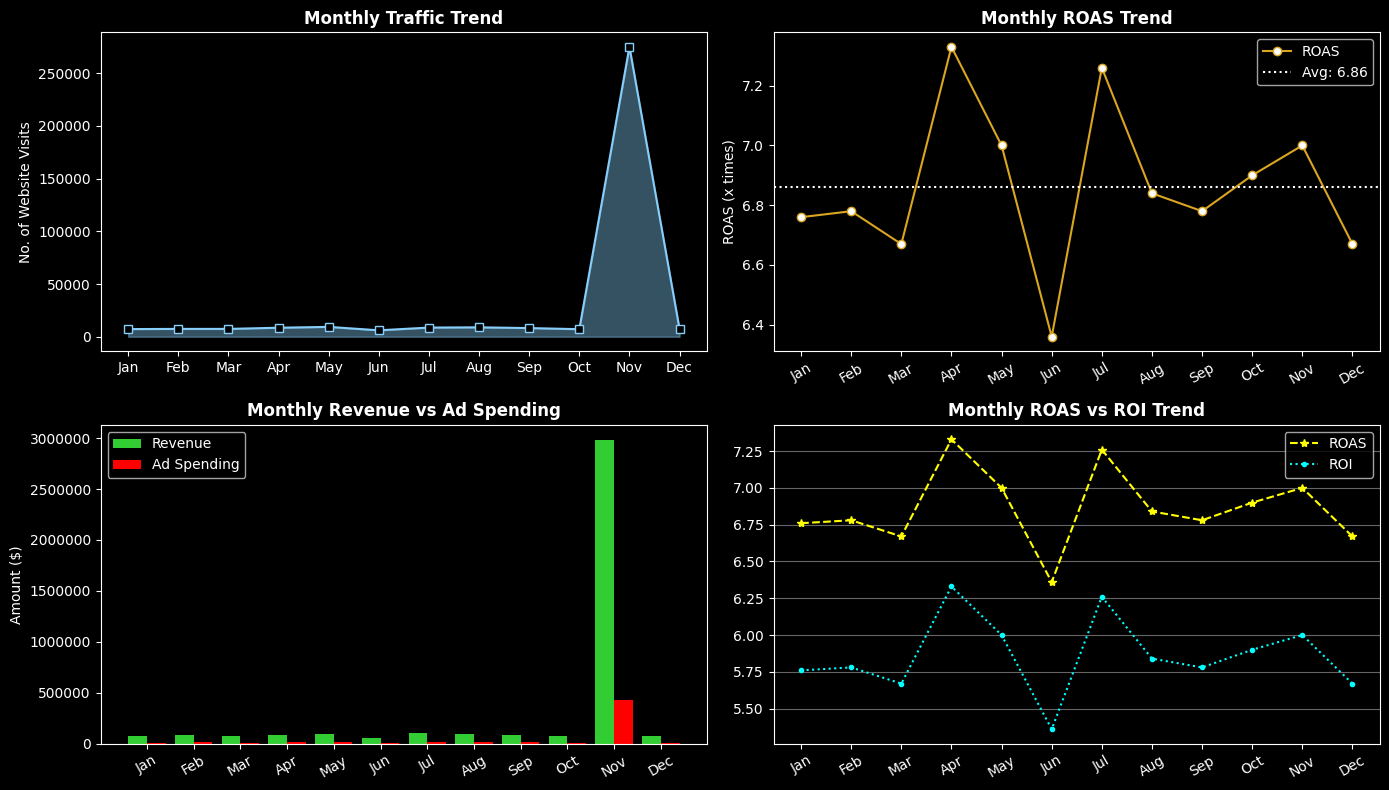

In [14]:
fig,axes = plt.subplots(2,2,figsize=(14,8))
axes[0,0].plot(monthly['Month Name'],monthly['Clicks'],color='lightskyblue',linestyle='-',marker="s",mfc='black')
axes[0,0].fill_between(monthly['Month Name'],monthly['Clicks'],color='lightskyblue',alpha=0.4)
axes[0,0].set_title('Monthly Traffic Trend',fontweight='bold')
axes[0,0].set_ylabel('No. of Website Visits')
axes[0,0].grid(False)
# ROAS Trend
axes[0,1].plot(monthly['Month Name'],monthly['ROAS'],marker='o',color='goldenrod',mfc='white',label='ROAS')
axes[0,1].set_xticks(monthly['Month Name'])
axes[0,1].set_xticklabels(monthly['Month Name'],rotation=30)
axes[0,1].set_title('Monthly ROAS Trend',fontweight='bold')
axes[0,1].set_ylabel('ROAS (x times)')
axes[0,1].axhline(monthly['ROAS'].mean(),color='white',linestyle=':',label=f"Avg: {monthly['ROAS'].mean().round(2)}")
axes[0,1].legend()
axes[0,1].grid(False)
# Revenue vs Ad_Spending
x = np.arange(len(monthly['Month Name']))
width = 0.4
axes[1,0].bar(x-width/2,monthly['Revenue'],width=width,label='Revenue',color='limegreen')
axes[1,0].bar(x + width/2,monthly['Spending'],width=width,label='Ad Spending',color='red')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(monthly['Month Name'],rotation=30)
axes[1,0].ticklabel_format(style='plain',axis='y')
axes[1,0].set_title('Monthly Revenue vs Ad Spending',fontweight='bold')
axes[1,0].set_ylabel('Amount ($)')
axes[1,0].legend()
axes[1,0].grid(False)
# ROI vs ROAS
roi = (monthly['ROI'].astype('float').astype('int')/100)
axes[1,1].plot(monthly['Month Name'],monthly['ROAS'],color='yellow',linestyle='--',marker="*",label='ROAS',)
axes[1,1].plot(monthly['Month Name'],roi,color='cyan',linestyle=':',marker='.',label='ROI')
axes[1,1].set_title('Monthly ROAS vs ROI Trend',fontweight='bold')
axes[1,1].set_xticklabels(monthly['Month Name'],rotation=30)
axes[1,1].legend()
axes[1,1].grid(axis='y',alpha=0.4)
plt.tight_layout()
plt.show()

November spike was too big — squishing all other months in the chart  
used log scale so other months are visible too

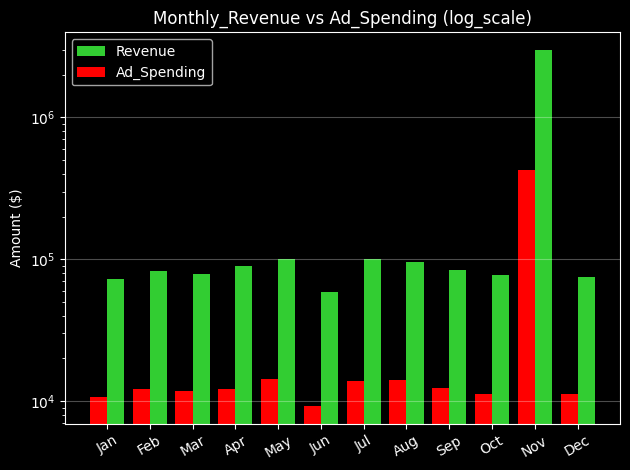

In [15]:
x=np.arange(len(monthly['Month Name']))
width=0.4
plt.bar(x+width/2,monthly['Revenue'],width=width,label='Revenue',color='limegreen')
plt.bar(x-width/2,monthly['Spending'],width=width,label='Ad_Spending',color='red')
plt.xticks(x,monthly['Month Name'])
plt.yscale('log')
plt.ylabel('Amount ($)')
plt.title('Monthly_Revenue vs Ad_Spending (log_scale)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.grid(axis='y',alpha=0.3)
plt.show()

## 6. Device Performance Analysis

Different users interact with ads on different devices,
In this section I want to compare:

- Revenue
- Spending
- Conversion Rate
- ROAS

across Desktop, Mobile and Tablet users.

The goal is to see whether device type affects campaign performance.

In [16]:
# Does device type matter?
device = df.groupby('Device').agg(
    Cost = ('Cost','sum'),
    Revenue = ('Sale_Amount','sum'),
    Clicks = ('Clicks','sum'),
    Impressions = ('Impressions','sum'),
    Conversions = ('Conversions','sum'),
    Leads       = ('Leads','sum'),
).reset_index()
device['ROAS'] = (device['Revenue']/device['Cost']).round(3)
device['CPC'] = (device['Cost']/device['Clicks']).round(3)
device['CTR'] = (device['Clicks']/device['Impressions']*100).round(3)
device['Revenue_Share']= (device['Revenue']/device['Revenue'].sum()*100).round(2)
print("="*70)
print("Device Performance Summary")
print("="*70)
device[['Device','Cost','Revenue','ROAS','Clicks','CPC','CTR','Revenue_Share']]

Device Performance Summary


,Device,Cost,Revenue,ROAS,Clicks,CPC,CTR,Revenue_Share
0,Desktop,190453.849321,1331672.25,6.992,121887,1.563,3.033,34.18
1,Mobile,189795.938074,1313738.80,6.922,123068,1.542,3.092,33.72
2,Tablet,178985.833060,1251074.30,6.990,116338,1.538,3.094,32.11


Three charts — revenue share as a donut, clicks comparison, and ROAS by device.  
The ROAS y-axis starts at 6.8 since all three are close — easier to spot the difference.

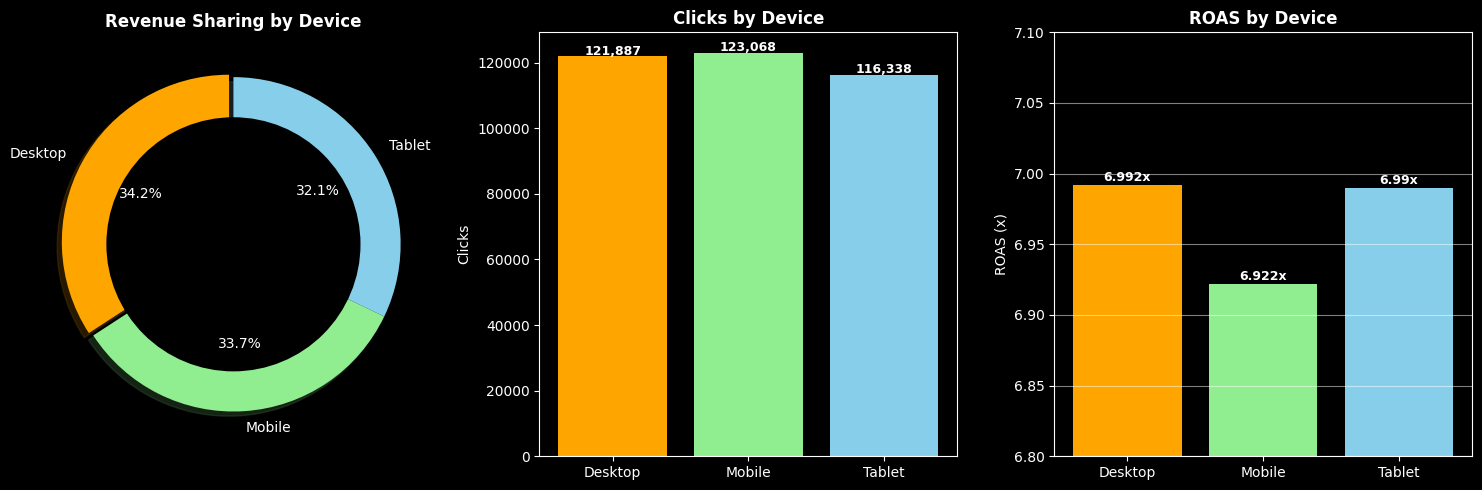

In [17]:
fig, axes = plt.subplots(1,3,figsize=(15, 5))
colors = ['orange', 'lightgreen', 'skyblue']
# Revenue
axes[0].pie(device['Revenue'],labels=device['Device'],explode=[0.03,0,0],colors=colors,shadow=True,autopct='%1.1f%%',startangle=90)
circle = plt.Circle((0,0),0.76,fc='black')
axes[0].add_artist(circle)
axes[0].set_title('Revenue Sharing by Device',fontweight='bold')
# Clicks
axes[1].bar(device['Device'],device['Clicks'],color=colors)
axes[1].set_title('Clicks by Device',fontweight='bold')
axes[1].set_ylabel('Clicks')
for i,j in enumerate(device['Clicks']):
    axes[1].text(i,j+500,f'{j:,}',ha='center',fontsize=9,weight='bold')
# ROAS
axes[2].bar(device['Device'],device['ROAS'],color=colors)
axes[2].set_title('ROAS by Device',fontweight='bold')
axes[2].set_ylabel('ROAS (x)')
axes[2].set_ylim(6.8,7.1)
for i,j in enumerate(device['ROAS']):
    axes[2].text(i,j+0.003,f'{j}x',ha='center',fontsize=9,weight='bold')
axes[2].grid(axis='y',alpha=0.5)
plt.tight_layout()
plt.show()


All three devices are surprisingly close. No single device is clearly better.
Mobile has most clicks at lowest cost — most efficient  
If I had to shift budget i'd move some from tablet to mobile

## 7. Keyword Performance Analysis

Keywords are one of the most important parts of digital marketing.

Here I will analyze which keywords generate:

- More revenue
- Better conversion rates
- Higher ROAS

This can help identify keywords that deserve more budget and keywords that may need optimization.

In [18]:
keyword = df.groupby('Keyword').agg(
    Revenue     = ('Sale_Amount', 'sum'),
    Spending      = ('Cost', 'sum'),
    Clicks      = ('Clicks', 'sum'),
    Conversions = ('Conversions', 'sum'),
    Leads       = ('Leads', 'sum')
).reset_index()
keyword['CPL'] = (keyword['Spending']/keyword['Leads']).round(2)
keyword['CPC']  = (keyword['Spending']/keyword['Clicks']).round(2)
keyword['ROAS'] = (keyword['Revenue']/keyword['Spending']).round(2)
keyword['ROI'] = ((keyword['Revenue']-keyword['Spending'])/keyword['Spending']).round(2)
keyword.sort_values('ROI',ascending=False,inplace=True)
keyword=keyword.reset_index(drop=True)
keyword

,Keyword,Revenue,Spending,Clicks,Conversions,Leads,CPL,CPC,ROAS,ROI
0,Data Analytics Course,664696.00,93803.278726,62288,2904,8913,10.52,1.51,7.09,6.09
1,Data Anaytics Training,620013.00,88460.698726,57705,2745,8108,10.91,1.53,7.01,6.01
2,Learn Data Analytics,674830.65,96293.648102,60366,2900,8917,10.80,1.60,7.01,6.01
3,Data Analytics Online,630199.10,90376.233088,58572,2684,8465,10.68,1.54,6.97,5.97
4,Analytics For Data,640703.35,92729.370595,59357,2757,8704,10.65,1.56,6.91,5.91
5,Online Data Analytics,666043.25,97572.391219,63005,2995,8903,10.96,1.55,6.83,5.83


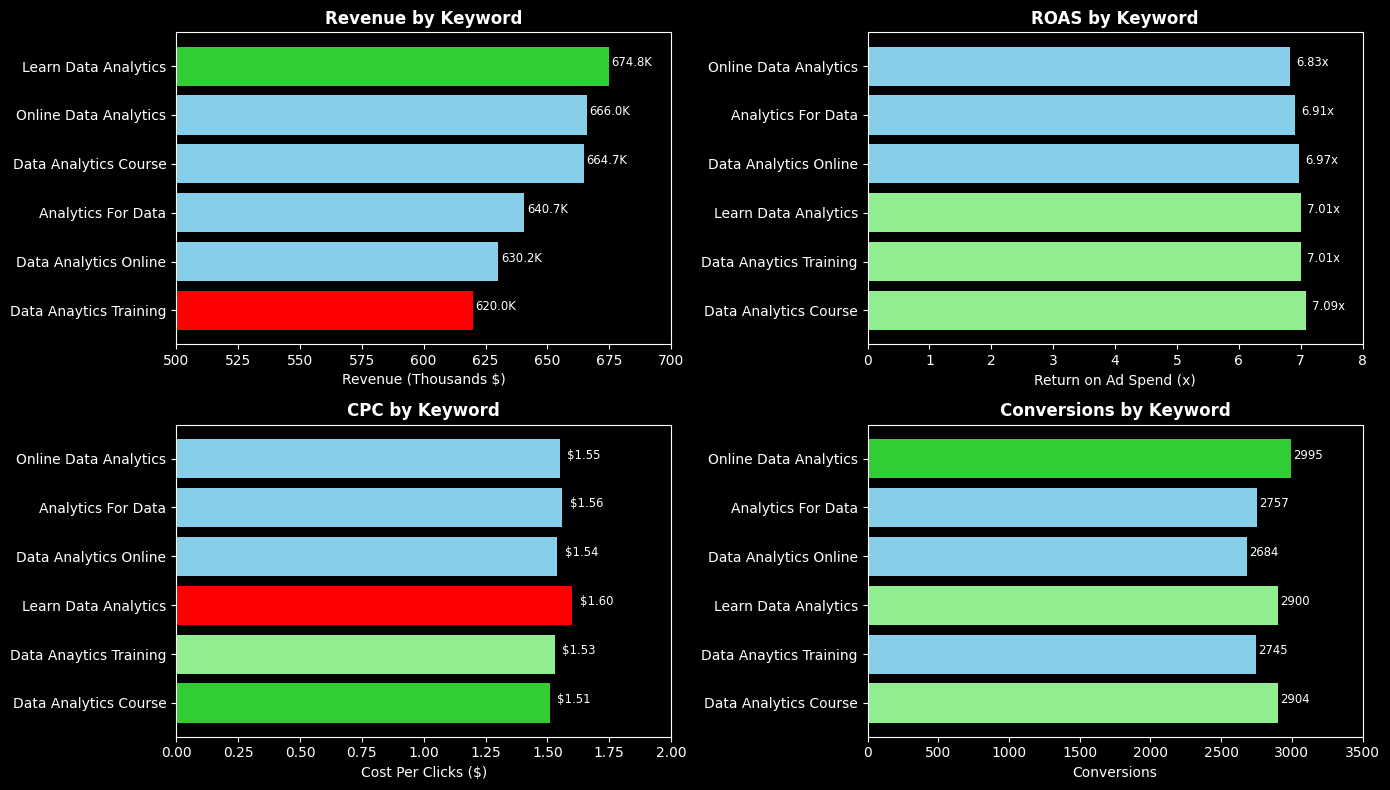

In [19]:
# Which keywords are actually working?
fig,axes=plt.subplots(2,2,figsize=(14,8))
# Revenue by keyword
sorted_data=sorted(zip(keyword['Revenue'],keyword['Keyword']),reverse=False)
key_revenue,key_keyword = zip(*sorted_data)
key_revenue = np.array(key_revenue)/1000
axes[0,0].barh(key_keyword,key_revenue,align='center',color=['red','skyblue','skyblue','skyblue','skyblue','limegreen'])
axes[0,0].set_xlim(500,700)
for index,values in enumerate((key_revenue).round(2)):
    axes[0,0].text(values+1,index,f'{values:.1f}K',fontsize='small')
axes[0,0].set_xlabel('Revenue (Thousands $)')
axes[0,0].set_title('Revenue by Keyword',fontweight='bold')
# # ROAS by keyword
axes[0,1].barh(keyword['Keyword'],keyword['ROAS'],align='center',color=['lightgreen','lightgreen','lightgreen','skyblue','skyblue','skyblue'])
for index,values in enumerate((keyword['ROAS'])):
    axes[0,1].text(values+0.1,index,f'{values:.2f}x',fontsize='small')
axes[0,1].set_xlabel('Return on Ad Spend (x)')
axes[0,1].set_xlim(0,8)
axes[0,1].set_title('ROAS by Keyword',fontweight='bold')
# CPC by Keyword
axes[1,0].barh(keyword['Keyword'],keyword['CPC'],align='center',color=['limegreen','lightgreen','red','skyblue','skyblue','skyblue'])
for index,values in enumerate((keyword['CPC'])):
    axes[1,0].text(values+0.03,index,f'${values:.2f}',fontsize='small')
axes[1,0].set_xlabel('Cost Per Clicks ($)')
axes[1,0].set_xlim(0,2)
axes[1,0].set_title('CPC by Keyword',fontweight='bold')
# Conversions by Keyword
axes[1,1].barh(keyword['Keyword'],keyword['Conversions'],align='center',color=['lightgreen','skyblue','lightgreen','skyblue','skyblue','limegreen'])
for index,values in enumerate((keyword['Conversions'])):
    axes[1,1].text(values+15,index,values,fontsize='small')
axes[1,1].set_xlabel('Conversions')
axes[1,1].set_xlim(0,3500)
axes[1,1].set_title('Conversions by Keyword',fontweight='bold')
plt.tight_layout()
plt.show()


CPC range is $1.51–$1.60, No keyword is wasting budget.  
"Data Analytics Course" has the best ROAS. "Online Data Analytics" drives most conversions but lowest ROAS.

In [20]:
# Checking column names
print(df.columns.to_list())

['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location', 'Device', 'Keyword', 'Month', 'Month Name', 'Month_Num', 'Day_of_Week', 'Week', 'CTR', 'CPC', 'CPL', 'ROAS', 'Profit', 'ROI']


## 8. Weekday Performance Analysis  
Customer behavior can vary across different days of the week.  
In this section I will compare campaign performance by weekday to identify when users are most active and when campaigns perform best.

In [21]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DOW = df.groupby('Day_of_Week').agg(
    Revenue = ('Sale_Amount','sum'),
    Spending = ('Cost','sum'),
    Clicks = ('Clicks','sum'),
    Conversions = ('Conversions','sum')
).reindex(order).reset_index()
DOW['ROI'] = ((DOW['Revenue']-DOW['Spending'])/DOW['Spending']).round(2)
DOW['ROAS'] = (DOW['Revenue']/DOW['Spending']).round(2)
DOW

,Day_of_Week,Revenue,Spending,Clicks,Conversions,ROI,ROAS
0,Monday,528892.05,75928.216856,49605,2276,5.97,6.97
1,Tuesday,401363.40,59168.457479,37921,1784,5.78,6.78
2,Wednesday,613796.00,88917.487479,56763,2747,5.90,6.90
3,Thursday,721110.30,102658.879349,67211,3090,6.02,7.02
4,Friday,568431.50,81241.001219,51484,2460,6.00,7.00
5,Saturday,572266.70,79539.551219,51813,2401,6.19,7.19
6,Sunday,490625.40,71782.026856,46496,2227,5.83,6.83


For avg daily clicks and conversions —  
First summed per date, then averaged across dates for each day  
direct .mean() on raw rows would be wrong because there are multiple rows per date (different devices, keywords)


In [22]:
avg_convers_mon = df[df['Day_of_Week']=='Monday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_tue = df[df['Day_of_Week']=='Tuesday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_wed = df[df['Day_of_Week']=='Wednesday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_thu = df[df['Day_of_Week']=='Thursday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_fri = df[df['Day_of_Week']=='Friday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_sat = df[df['Day_of_Week']=='Saturday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_sun = df[df['Day_of_Week']=='Sunday'].groupby('Ad_Date')['Conversions'].sum().mean()
avg_convers_daily = [avg_convers_mon,avg_convers_tue,avg_convers_wed,avg_convers_thu,avg_convers_fri,avg_convers_sat,avg_convers_sun]

In [23]:
avg_clicks_mon = df[df['Day_of_Week']=='Monday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_tue = df[df['Day_of_Week']=='Tuesday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_wed = df[df['Day_of_Week']=='Wednesday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_thu = df[df['Day_of_Week']=='Thursday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_fri = df[df['Day_of_Week']=='Friday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_sat = df[df['Day_of_Week']=='Saturday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_sun = df[df['Day_of_Week']=='Sunday'].groupby('Ad_Date')['Clicks'].sum().mean()
avg_clicks_daily = [avg_clicks_mon,avg_clicks_tue,avg_clicks_wed,avg_clicks_thu,avg_clicks_fri,avg_clicks_sat,avg_clicks_sun]

In [24]:
avg_clicks_daily = np.array(avg_clicks_daily).round()
avg_convers_daily = np.array(avg_convers_daily).round()
print(avg_clicks_daily)

[9921. 7584. 9460. 9602. 8581. 8636. 7749.]


Average Daily Traffic and Conversions by day

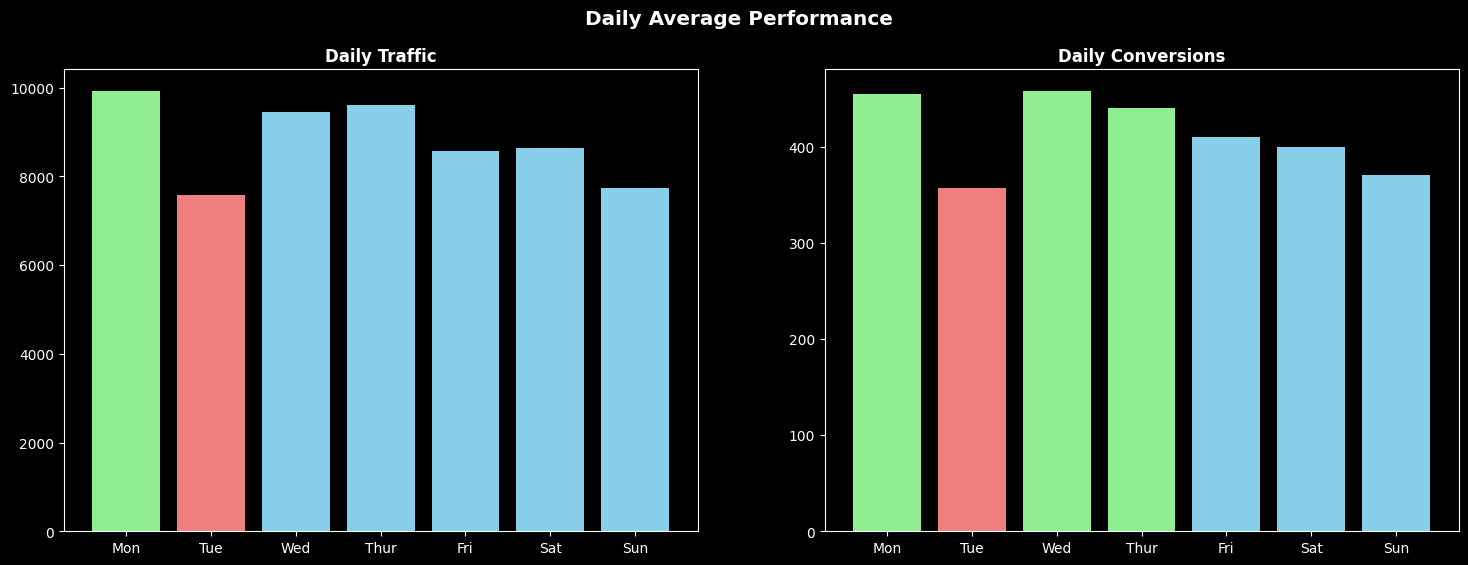

In [25]:
order_short=['Mon','Tue','Wed','Thur','Fri','Sat','Sun']
fig,axes = plt.subplots(1,2,figsize=(18,6))
axes[0].bar(order_short,avg_clicks_daily,align='center',color=['lightgreen','lightcoral','skyblue','skyblue','skyblue','skyblue','skyblue'])
axes[0].set_title('Daily Traffic',fontweight='bold')
axes[1].bar(order_short,avg_convers_daily,align='center',color=['lightgreen','lightcoral','lightgreen','lightgreen','skyblue','skyblue','skyblue'])
axes[1].set_title('Daily Conversions',fontweight='bold')
plt.suptitle('Daily Average Performance',fontweight='bold',fontsize='x-large')
plt.show()

In [26]:
print("="*70)
print("Weekdays Performance Summary")
print("="*70)
DOW

Weekdays Performance Summary


,Day_of_Week,Revenue,Spending,Clicks,Conversions,ROI,ROAS
0,Monday,528892.05,75928.216856,49605,2276,5.97,6.97
1,Tuesday,401363.40,59168.457479,37921,1784,5.78,6.78
2,Wednesday,613796.00,88917.487479,56763,2747,5.90,6.90
3,Thursday,721110.30,102658.879349,67211,3090,6.02,7.02
4,Friday,568431.50,81241.001219,51484,2460,6.00,7.00
5,Saturday,572266.70,79539.551219,51813,2401,6.19,7.19
6,Sunday,490625.40,71782.026856,46496,2227,5.83,6.83


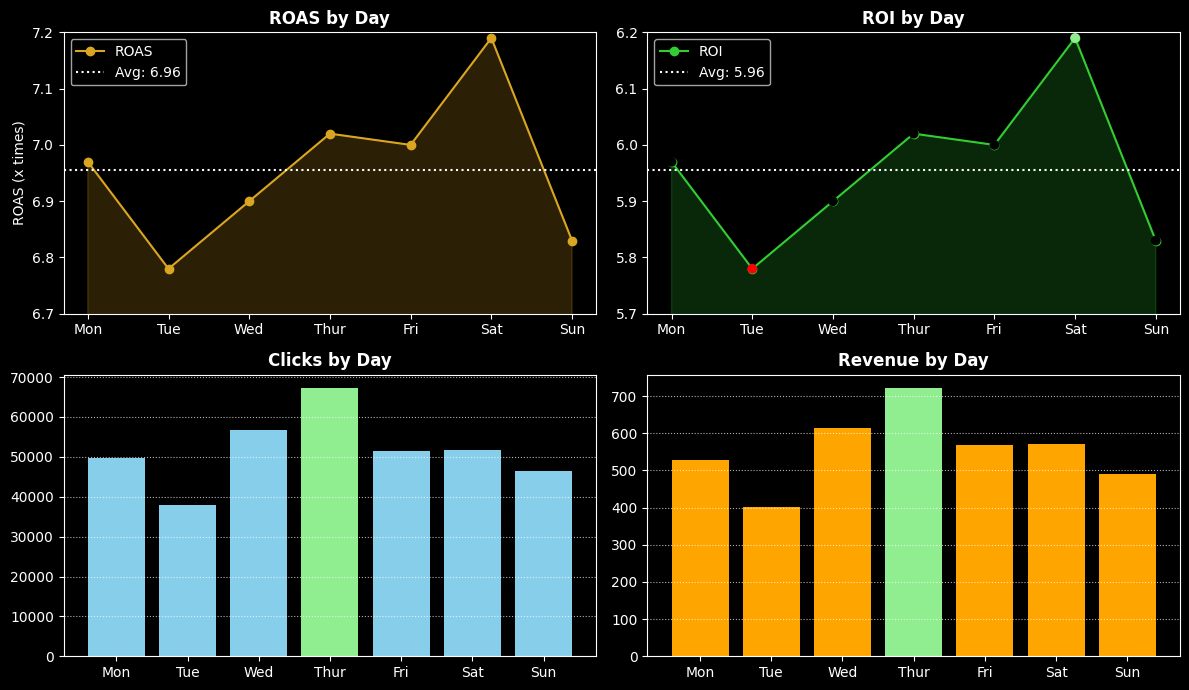

In [27]:
fig, axes = plt.subplots(2,2,figsize=(12,7))
# ROAS
axes[0,0].plot(order_short,DOW['ROAS'],marker='o',color='goldenrod',label='ROAS')
axes[0,0].fill_between(order_short,0,DOW['ROAS'],color='goldenrod',alpha=0.2)
axes[0,0].set_title('ROAS by Day',fontweight='bold')
axes[0,0].set_ylabel('ROAS (x times)')
axes[0,0].axhline(DOW['ROAS'].mean(),color='white',linestyle=':',label=f"Avg: {DOW['ROAS'].mean().round(2)}")
axes[0,0].set_ylim(6.7,7.2)
axes[0,0].legend()
axes[0,0].grid(False)

# ROI 
axes[0,1].plot(order_short,DOW['ROI'],color='limegreen', marker='o',label='ROI')
axes[0,1].fill_between(order_short,0,DOW['ROI'],alpha=0.2,color='limegreen')
axes[0,1].axhline(DOW['ROI'].mean(),color='white',linestyle=':',label=f"Avg: {DOW['ROI'].mean().round(2)}")
color = ['black', 'red', 'black', 'black', 'black', 'lightgreen', 'black']
axes[0, 1].scatter(order_short,DOW['ROI'],color=color,zorder=5)
axes[0,1].set_ylim(5.7,6.2)
axes[0,1].set_title('ROI by Day',fontweight='bold')
axes[0,1].legend()
# Clicks
axes[1,0].bar(order_short,DOW['Clicks'],color=['skyblue','skyblue','skyblue','lightgreen','skyblue','skyblue','skyblue'])
axes[1,0].set_title('Clicks by Day',fontweight='bold')
axes[1,0].grid(axis='y',alpha=0.7,linestyle=':')
# Revenue
axes[1,1].bar(order_short,DOW['Revenue']/1000,color=['orange','orange','orange','lightgreen','orange','orange','orange'])
axes[1,1].set_title('Revenue by Day',fontweight='bold')
axes[1,1].grid(axis='y',alpha=0.7,linestyle=':')
plt.tight_layout()
plt.show()


thursday — highest clicks and conversions  
saturday — best roas even though not the busiest day  
tuesday — weakest across everything  
would push budget toward thu-sat and reduce tuesday

## 9. Relationship Between Marketing Metrics

A single metric rarely tells the complete story.

In this section we will try to found out how business metrics are related to each other.

This may help identify factors that influence revenue and conversions.

In [28]:
import seaborn as sns

<Axes: >

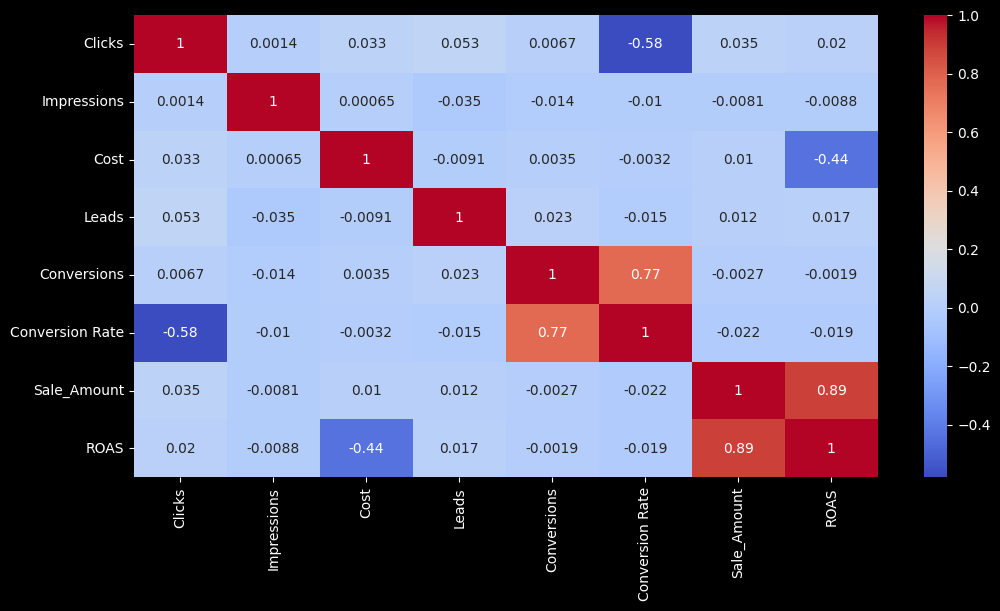

In [29]:
# Relation b/w Business Matrix/Main Features
df_corr = df[['Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions',
        'Conversion Rate', 'Sale_Amount', 'ROAS']]
plt.figure(figsize=(12,6))
sns.heatmap(df_corr.corr(),cmap='coolwarm',annot=True)

#### Observations from Correlation Heatmap

I wanted to check whether any of the marketing metrics move together and if there are any strong relationships in the dataset.

Some interesting patterns stood out:

* Sale Amount and ROAS have a very strong positive correlation (0.89). This makes sense because campaigns generating higher revenue tend to produce better returns on ad spend.

* Conversions and Conversion Rate also show a strong positive relationship (0.77). Campaigns with more conversions generally have higher conversion efficiency.

* Clicks and Conversion Rate show a moderate negative correlation (-0.58). This suggests that simply increasing traffic does not guarantee better conversion performance. In some cases, campaigns with large numbers of clicks may attract lower-quality traffic.

* Cost and ROAS have a moderate negative correlation (-0.44). Higher spending does not automatically lead to better returns, which highlights the importance of campaign efficiency rather than budget size alone.

* Most other correlations are close to zero, indicating weak or no linear relationship between those variables.

Overall, the heatmap suggests that revenue generation and conversion efficiency have a stronger impact on campaign success than raw traffic volume alone.


In [30]:
# Analysing November boom!
nov    = df[df['Month_Num'] == 11]
others = df[df['Month_Num'] != 11]

print("="*30)
print('November v/s Other Months')
print('='*30)
print(f"Nov Revenue   : ${nov['Sale_Amount'].sum():,.0f}")
print(f"Nov Spending  : ${nov['Cost'].sum():,.0f}")
print(f"Nov ROAS      : {nov['Sale_Amount'].sum()/nov['Cost'].sum():.2f}x")
print(f"Nov Conversions: {nov['Conversions'].sum():,}")
print(f"Other months avg revenue: ${others.groupby('Month')['Sale_Amount'].sum().mean():,.0f}")
print(f"November revenue : ${nov['Sale_Amount'].sum():,.0f}")


November v/s Other Months
Nov Revenue   : $2,981,376
Nov Spending  : $426,039
Nov ROAS      : 7.00x
Nov Conversions: 12,943
Other months avg revenue: $83,192
November revenue : $2,981,376


In [31]:
nov['Cost'].sum()/df['Cost'].sum()*100
nov['Sale_Amount'].sum()/df['Sale_Amount'].sum()*100

np.float64(76.51448760098634)

## 10. November Performance Investigation
In this section I will investigate:

- Revenue contribution
- Spending contribution
- Device performance
- Keyword performance

to understand the reasons behind this increase

Visual comparison — November vs rest of year for both spend and revenue.

Text(0.5, 1.0, 'Revenue Sharing by November')

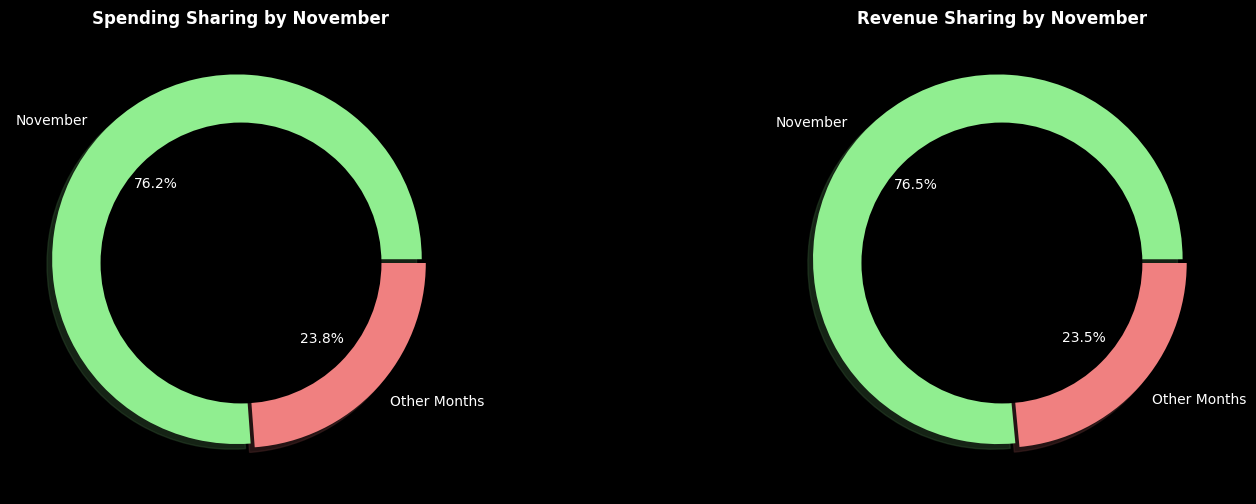

In [32]:
# November vs Rest of year — Spend and Revenue
nov_spending = nov['Cost'].sum()
others_spending = df['Cost'].sum()-nov['Cost'].sum()
nov_revenue = nov['Sale_Amount'].sum()
others_revenue = df['Sale_Amount'].sum()-nov['Sale_Amount'].sum()
fig,axes=plt.subplots(1,2,figsize=(18,6))
axes[0].pie([nov_spending,others_spending],labels=['November','Other Months'],explode=[0.03,0],colors=['lightgreen','lightcoral'],shadow=True,autopct='%1.1f%%')
circle = plt.Circle((0,0),0.76,fc='black')
axes[0].add_artist(circle)
axes[0].set_title('Spending Sharing by November',fontweight='bold')
axes[1].pie([nov_revenue,others_revenue],labels=['November','Other Months'],explode=[0.03,0],colors=['lightgreen','lightcoral'],shadow=True,autopct='%1.1f%%')
circle = plt.Circle((0,0),0.76,fc='black')
axes[1].add_artist(circle)
axes[1].set_title('Revenue Sharing by November',fontweight='bold')

In [33]:
# November top keywords
nov['Keyword'].value_counts().reset_index()

,Keyword,count
0,Online Data Analytics,351
1,Data Analytics Course,345
2,Learn Data Analytics,341
3,Analytics For Data,325
4,Data Analytics Online,316
5,Data Anaytics Training,307


Same check for Devices inside November

In [34]:
print('='*50)
print('November Month Device Performance')
print('='*50)
print(nov.groupby('Device')[['Cost','Sale_Amount','Conversions']].sum().round().reset_index())
print('='*50)
print('Other Months Device Performance')
print('='*50)
print(others.groupby('Device')[['Cost','Sale_Amount','Conversions']].sum().round().reset_index())

November Month Device Performance
    Device      Cost  Sale_Amount  Conversions
0  Desktop  142720.0    1007154.0         4387
1   Mobile  144631.0    1001664.0         4408
2   Tablet  138688.0     972558.0         4148
Other Months Device Performance
    Device     Cost  Sale_Amount  Conversions
0  Desktop  47734.0     324518.0         1441
1   Mobile  45165.0     312074.0         1391
2   Tablet  40298.0     278517.0         1210


# Key Findings

| Finding | Recommendation |
|----------|----------|
| ROAS = 6.97x | Campaign is profitable and can be scaled |
| November generated 76% of revenue | Reduce dependency on a single month |
| Mobile delivered the best efficiency | Shift some Tablet budget to Mobile |
| "DA Course" had the highest ROAS | Increase bids on this keyword |
| Thursday had most conversions | Increase budget on Thursdays |
| Saturday had best ROAS | Prioritize spending on Saturdays |
| Tuesday was the weakest day | Reduce Tuesday budget allocation |
| More clicks did not mean better conversion rate | Focus on traffic quality and landing pages |
| June had the lowest ROAS | Run promotional campaigns during slow months |

---

### Business Takeaway

The campaigns are highly profitable, but performance is concentrated in a few specific months, keywords, devices and weekdays. Future optimization should focus on scaling high-ROAS segments while reducing spend on underperforming areas.